# Efficient LLM Serving at Scale with Unified Caching (vLLM + LMCache)

**The idea:** vLLM keeps its prefix (KV) cache in GPU memory. When many long requests overflow that GPU pool, their KV gets **evicted and recomputed** on every reuse. LMCache adds a **CPU-DRAM tier**: evicted KV is **reloaded from host memory** instead of recomputed, cutting time-to-first-token (TTFT).

**The experiment:** run one overflow workload twice -- a cold pass, then an identical warm pass -- under two servers:

| Server | Warm-pass TTFT |
|---|---|
| vLLM prefix cache only | stays high -- the working set exceeds the GPU pool, so it is recomputed every pass |
| vLLM prefix cache **+ LMCache** | **drops sharply** -- evicted KV is reloaded from CPU |

**Requirements**
- Runs inside `vllm/vllm-openai-rocm:v0.23.0` on one AMD GPU (ROCm).
- Model `Qwen/Qwen3-8B` staged locally (Cell 1b).
- LMCache **built from source with `BUILD_WITH_HIP=1`** (Cell 1) -- the PyPI wheel is CUDA-only and silently falls back to a slow copy path on ROCm.
- Workload: 24 requests, 32K input tokens each, concurrency 4 -- deliberately larger than the GPU KV pool so it overflows.

## 1. Build LMCache for ROCm (`BUILD_WITH_HIP=1`)

`pip install lmcache` ships CUDA-only compiled ops that fail to load on ROCm; LMCache then silently falls back to a slow copy path and the warm pass is no faster than recompute. So on AMD you must **build from source with `BUILD_WITH_HIP=1`**, which compiles the HIP ops using the ROCm toolchain (`hipcc`) already in the vLLM-ROCm image.

The cell also force-reinstalls the ROCm CuPy (`cupy-rocm-7-0`) and re-pins `grpcio`/`numpy` to the versions vLLM needs. It is idempotent -- if a working HIP build already imports, it is skipped.

**Requirement:** the verify block must print **`c_ops loaded OK`** and **`is_hip = True`**. Otherwise you are on the slow fallback path and the warm-pass win will not appear.

In [1]:
%%bash
set -e
LMCACHE_VERSION=v0.5.0

# 1) Build LMCache from source WITH HIP (compiles the ROCm c_ops; pip wheels are CUDA-only).
#    Skip if a working HIP c_ops already imports (idempotent re-runs).
if python3 -c "from lmcache import c_ops" 2>/dev/null; then
  echo "HIP c_ops already present - skipping build"
else
  command -v hipcc >/dev/null || { echo "ERROR: hipcc not found - need the ROCm toolchain to build"; exit 1; }
  pip uninstall -y lmcache >/dev/null 2>&1 || true
  cd /tmp && rm -rf LMCache
  git clone --depth 1 --branch "$LMCACHE_VERSION" https://github.com/LMCache/LMCache.git 2>&1 | tail -1
  cd LMCache
  echo "building LMCache $LMCACHE_VERSION with BUILD_WITH_HIP=1 (~3-5 min)..."
  BUILD_WITH_HIP=1 pip install -e . --no-build-isolation 2>&1 | tail -2
fi

# 2) ROCm CuPy (force-reinstall so it isn't left half-removed)
pip uninstall -y cupy cupy-cuda12x cupy-cuda13x nixl nixl-cu12 nixl-cu13 nixl_ep >/dev/null 2>&1 || true
pip install --force-reinstall --no-cache-dir cupy-rocm-7-0 2>&1 | tail -1

# 3) Re-pin deps the source build / cupy pull in (grpcio must match vLLM; numpy 2.5 breaks the image)
pip install -q "numpy==2.1.3" "grpcio==1.78.0" 2>&1 | tail -1 || true

echo "---- verify (must show 'c_ops loaded OK' and is_hip = True) ----"
python3 -c "
import lmcache
from lmcache import c_ops              # ImportError here => still on the slow CUDA-wheel fallback
print('c_ops loaded OK')
import cupy
from cupy_backends.cuda.api import runtime as r
assert getattr(r, 'is_hip', False), 'CuPy is not the ROCm build (is_hip=False)'
print('lmcache', lmcache.__version__, '| cupy', cupy.__version__, '| is_hip =', r.is_hip)
"

HIP c_ops already present - skipping build


---- verify (must show 'c_ops loaded OK' and is_hip = True) ----


[2026-07-03 00:11:41,255] LMCache INFO:  torch_dev=<module 'torch.cuda' from '/usr/local

/lib/python3.12/dist-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:62:l

mcache)


...

INFO: Skipping backend lmcache.xpu_ops: predicate returned False (__init__.py:102:lmcache)[

0m


[2026-07-03 00:11:41,376] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:12

0:lmcache)


c_ops loaded OK
lmcache 0.5.0 | cupy 14.1.1 | is_hip = True


## 1b. Fetch the model (one-time)

Downloads `Qwen/Qwen3-8B` to `/models/Qwen3-8B` if it is not already present. Qwen3 is ungated, so no token is required. Skip this cell if the model is already staged.

In [2]:
%%bash
# Qwen3-8B is ungated, so this works without a token; setting HF_TOKEN only
# raises the download rate limit. Skips if the model is already staged.
if [ ! -f /models/Qwen3-8B/config.json ]; then
  hf download Qwen/Qwen3-8B --local-dir /models/Qwen3-8B 2>&1 | tail -2
else
  echo "Qwen3-8B already present at /models/Qwen3-8B"
fi

Qwen3-8B already present at /models/Qwen3-8B


## 2. Baseline server -- vLLM prefix cache only

`--gpu-memory-utilization 0.5` keeps the GPU KV pool small so the 24x32K workload overflows it and evicted KV is recomputed on reuse. Prefix caching is on by default in vLLM. The server launches in the background; the next cell waits for it.

In [3]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null || true

# Baseline: vLLM with its default in-GPU prefix cache, no CPU offload.
# --gpu-memory-utilization 0.5 keeps the GPU KV pool small so the 24x32K-token
# workload overflows it -- evicted KV then has to be recomputed on reuse.
nohup vllm serve /models/Qwen3-8B \
  --served-model-name Qwen3-8B \
  --tensor-parallel-size 1 \
  --max-model-len 32768 \
  --gpu-memory-utilization 0.5 \
  > /tmp/vllm.log 2>&1 &
echo "launching baseline server (log: /tmp/vllm.log); first boot ~2-3 min"

launching baseline server (log: /tmp/vllm.log); first boot ~2-3 min


## 3. Wait for the server (live log)

Polls `/v1/models` and prints the tail of the server log each attempt, so you can watch weight-load → compile → ready.

In [4]:
import time, requests, subprocess
for i in range(80):
    try:
        if requests.get("http://localhost:8000/v1/models", timeout=5).ok:
            print("\n==> server ready"); break
    except requests.RequestException:
        pass
    tail = subprocess.run(["tail","-n","3","/tmp/vllm.log"], capture_output=True, text=True).stdout
    print(f"--- waiting {i+1}/80 ---\n{tail}", flush=True)
    time.sleep(10)
else:
    raise RuntimeError("server did not start - see /tmp/vllm.log")

==> server ready


## 4. Benchmark the baseline (two passes)

`vllm bench serve` with a fixed `--seed`, run twice: **PASS 1 (cold)** populates the cache and **PASS 2 (warm)** re-sends the identical prompts. Because the working set overflows the GPU pool, **PASS 2 ~ PASS 1** for the baseline -- evicted KV is recomputed, so warming gives no benefit.

In [5]:
import subprocess, re

def bench():
    cmd = ["vllm","bench","serve",
        "--model","Qwen3-8B","--tokenizer","/models/Qwen3-8B",
        "--base-url","http://localhost:8000","--endpoint","/v1/completions",
        "--dataset-name","random","--random-input-len","32000","--random-output-len","64",
        "--num-prompts","24","--max-concurrency","4","--seed","555","--ignore-eos",
        "--percentile-metrics","ttft"]
    out = subprocess.run(cmd, capture_output=True, text=True).stdout
    m = re.search(r"Mean TTFT \(ms\):\s*([0-9.]+)", out)
    return float(m.group(1))/1000 if m else None

prefix_cold = bench(); print(f"prefix-only  PASS1 cold: {prefix_cold:6.2f} s")
prefix_warm = bench(); print(f"prefix-only  PASS2 warm: {prefix_warm:6.2f} s   ({prefix_cold/prefix_warm:.2f}x)")

prefix-only  PASS1 cold:   9.63 s


prefix-only  PASS2 warm:   9.40 s   (1.02x)


## 5. Restart with LMCache -- prefix cache + CPU KV offload

A separate `lmcache server` holds KV in CPU DRAM; vLLM talks to it via `LMCacheMPConnector`. Same model and same GPU budget as the baseline -- the only change is the added CPU cache tier.

In [6]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null && sleep 2 || true

# CPU-DRAM KV cache server. --l1-size-gb pins that many GiB of host RAM up front,
# so it must fit comfortably in available RAM.
nohup lmcache server \
  --host 127.0.0.1 --port 5555 \
  --l1-size-gb 150 --eviction-policy LRU --chunk-size 256 \
  > /tmp/lmcache_server.log 2>&1 &
sleep 6

# Same vLLM server as the baseline, now pointed at the LMCache server so evicted
# KV is offloaded to (and reloaded from) CPU DRAM instead of being recomputed.
nohup vllm serve /models/Qwen3-8B \
  --served-model-name Qwen3-8B \
  --tensor-parallel-size 1 \
  --max-model-len 32768 \
  --gpu-memory-utilization 0.5 \
  --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both"}' \
  > /tmp/vllm.log 2>&1 &
echo "launching prefix+LMCache server; first boot ~2-3 min"

launching prefix+LMCache server; first boot ~2-3 min


## 6. Wait for the LMCache server

In [7]:
for i in range(80):
    try:
        if requests.get("http://localhost:8000/v1/models", timeout=5).ok:
            print("\n==> server ready"); break
    except requests.RequestException:
        pass
    tail = subprocess.run(["tail","-n","3","/tmp/vllm.log"], capture_output=True, text=True).stdout
    print(f"--- waiting {i+1}/80 ---\n{tail}", flush=True)
    time.sleep(10)
else:
    raise RuntimeError("server did not start - see /tmp/vllm.log")

==> server ready


## 7. Benchmark with LMCache (same two passes)

Identical workload. Now **PASS 2 << PASS 1**: evicted KV is reloaded from CPU instead of recomputed, so the warm pass drops sharply.

In [8]:
lmcache_cold = bench(); print(f"LMCache  PASS1 cold: {lmcache_cold:6.2f} s")
lmcache_warm = bench(); print(f"LMCache  PASS2 warm: {lmcache_warm:6.2f} s   ({lmcache_cold/lmcache_warm:.2f}x)")

LMCache  PASS1 cold:  12.91 s


LMCache  PASS2 warm:   0.32 s   (39.80x)


## 8. Proof it was the cache

LMCache exposes cache activity on its Prometheus endpoint (`:8080/metrics`). On the warm pass, `lmcache_mp_lookup_hit_tokens_total` climbs above 0 -- evicted KV was **reloaded from CPU**, not recomputed. If `requested` grows but `hit` stays 0, the cache keys are not matching between passes.

In [9]:
%%bash
# LMCache reports cache activity via its Prometheus endpoint (:8080/metrics),
# not the server log. lookup_hit_tokens climbing > 0 on the warm pass is the
# proof that evicted KV was reloaded from CPU instead of recomputed.
echo "---- store activity (server log) ----"
grep -cE "Stored [0-9]+ tokens" /tmp/lmcache_server.log | sed 's/^/store ops: /'
echo "---- lookup hits vs requests (metrics) ----"
curl -s http://localhost:8080/metrics \
  | grep -E "lmcache_mp_lookup_(hit|requested)_tokens_total" \
  | grep -v '^#' || echo "metrics endpoint not reachable"

---- store activity (server log) ----


store ops: 114


---- lookup hits vs requests (metrics) ----


lmcache_mp_lookup_requested_tokens_total{cache_salt="",model_name="/models/Qwen3-8B"} 1.536e+06
lmca

che_mp_lookup_hit_tokens_total{cache_salt="",model_name="/models/Qwen3-8B"} 768000.0


## 9. The warm-pass result

The cold pass only populates the cache, so it is not plotted. The **warm pass** is the story: prefix-only stays high because it recomputes the evicted KV, while prefix+LMCache drops sharply because it reloads that KV from CPU. The right panel headlines the speedup.

Warm TTFT: prefix-only 9.40s vs LMCache 0.32s -> 29.0x faster


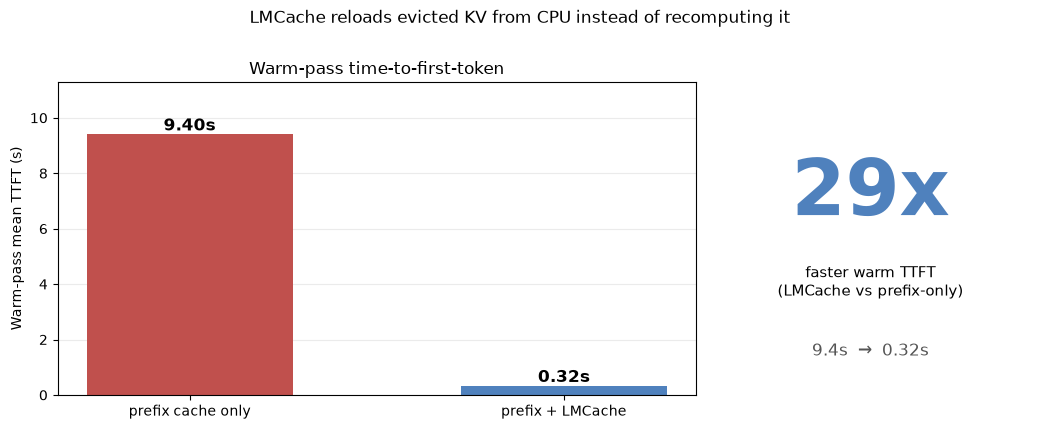

In [10]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--root-user-action=ignore", "matplotlib"])

import matplotlib.pyplot as plt
import numpy as np

# Warm pass only -- the cold pass merely populates the cache; the warm pass is the result.
labels = ["prefix cache only", "prefix + LMCache"]
warm   = [prefix_warm, lmcache_warm]
warm_speedup = prefix_warm / lmcache_warm
C_PREFIX, C_LMC = "#c0504d", "#4f81bd"

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2),
                              gridspec_kw={"width_ratios": [2, 1]})

# Panel 1 -- warm-pass TTFT, one bar per server
x = np.arange(2)
bars = ax.bar(x, warm, width=0.55, color=[C_PREFIX, C_LMC])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Warm-pass mean TTFT (s)")
ax.set_title("Warm-pass time-to-first-token")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.set_ylim(0, max(warm) * 1.2)
for b, v in zip(bars, warm):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

# Panel 2 -- speedup headline
ax2.axis("off")
ax2.text(0.5, 0.64, f"{warm_speedup:.0f}x", ha="center", va="center",
         fontsize=56, fontweight="bold", color=C_LMC)
ax2.text(0.5, 0.36, "faster warm TTFT\n(LMCache vs prefix-only)",
         ha="center", va="center", fontsize=11)
ax2.text(0.5, 0.14, f"{prefix_warm:.1f}s  \u2192  {lmcache_warm:.2f}s",
         ha="center", va="center", fontsize=12, color="#555")

fig.suptitle("LMCache reloads evicted KV from CPU instead of recomputing it",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"Warm TTFT: prefix-only {prefix_warm:.2f}s vs LMCache {lmcache_warm:.2f}s "
      f"-> {warm_speedup:.1f}x faster")

## 10. When does LMCache help?

Only when **both** hold:

| Condition | Why |
|---|---|
| **Long context reused** | Reload only pays off when recompute (long prefill) is expensive. |
| **GPU HBM under pressure** | If the working set fits in GPU, vLLM's prefix cache already serves reuse and LMCache just adds transfer cost. |

That is why this demo overflows a small GPU pool with long requests. With a single short request, or a GPU pool large enough to hold the working set, prefix caching alone is enough and LMCache shows no benefit -- that is expected.

### AMD / ROCm requirements
- **Build LMCache with `BUILD_WITH_HIP=1`** (Cell 1) -- the #1 pitfall. The PyPI wheel is CUDA-only, fails to load on ROCm, and silently falls back to a slow copy path that makes the warm pass no faster than recompute. Verify `c_ops loaded OK` / `is_hip = True`.
- **`cupy-rocm-7-0` (force-reinstall)** -- otherwise the cache server can hang at startup.
- **`LMCacheMPConnector` with a separate `lmcache server`** -- the in-engine connector can fault under concurrency on ROCm.
- **`--l1-size-gb` must fit available host RAM** -- it pins that many GiB up front.

### Model note: use a standard-attention model
Models with **sliding-window attention + heterogeneous head_dim** **store** KV into LMCache but return **0 lookup hits** (cache-key/layout mismatch), so they show no warm-pass win even with a correct HIP build. Qwen3, Llama3, and Qwen-VL work well.

## 11. Live side-by-side: one prompt, two servers on one GPU

The benchmark above ran the two configurations one after another. Here we run them **at the same time** — a baseline vLLM (prefix cache only) on port 8001 and an LMCache-backed vLLM on port 8000, both serving Qwen3-8B on the **same GPU**.

To fit two copies on one GPU we shrink each one's footprint: `--max-model-len 16384` plus a small, fixed KV pool (`--num-gpu-blocks-override 1280`, ~20K tokens). That small pool is also what makes the demo work — a long shared document gets **evicted from the baseline's GPU cache** by later traffic, while LMCache keeps it in CPU DRAM.

We then send **one identical request** (the document + a question) to both and compare time-to-first-token: the baseline recomputes the whole document, LMCache reloads it from CPU.

In [11]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null && sleep 2 || true

wait_ready () {  # $1=port $2=log $3=name
  for i in $(seq 1 60); do
    [ "$(curl -s -o /dev/null -w '%{http_code}' --max-time 3 http://localhost:$1/v1/models 2>/dev/null)" = "200" ] && { echo "$3 ready"; return 0; }
    grep -qE "No available memory|Engine core initialization failed" "$2" && { echo "$3 BOOT ERROR (see $2)"; return 1; }
    sleep 5
  done; echo "$3 timeout"; return 1
}

# CPU-DRAM KV server for the LMCache side
nohup lmcache server --host 127.0.0.1 --port 5555 \
  --l1-size-gb 40 --eviction-policy LRU --chunk-size 256 \
  > /tmp/lmcache_server.log 2>&1 &
sleep 6

# Both servers share one GPU: small max-model-len + a forced small KV pool so both fit.
COMMON="--tensor-parallel-size 1 --max-model-len 16384 --gpu-memory-utilization 0.30 \
  --num-gpu-blocks-override 1280 --max-num-batched-tokens 2048 --max-num-seqs 8 --enforce-eager"

# Boot sequentially (each fully up before the next) so their memory profiling doesn't collide.
nohup vllm serve /models/Qwen3-8B --served-model-name Qwen3-8B $COMMON \
  --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both"}' \
  --port 8000 > /tmp/vllm_lmcache.log 2>&1 &
wait_ready 8000 /tmp/vllm_lmcache.log "LMCache server (:8000)" || exit 1

nohup vllm serve /models/Qwen3-8B --served-model-name Qwen3-8B $COMMON \
  --port 8001 > /tmp/vllm_baseline.log 2>&1 &
wait_ready 8001 /tmp/vllm_baseline.log "baseline server (:8001)" || exit 1

grep -m1 "GPU KV cache size" /tmp/vllm_lmcache.log
echo "both servers up on one GPU"


LMCache server (:8000) ready


baseline server (:8001) ready


(EngineCore pid=5826) INFO 07-03 01:12:20 [kv_cache_utils.py:1744] GPU KV cache size: 20,480 tokens


both servers up on one GPU


In [12]:
import time, json, re, threading, requests
from transformers import AutoTokenizer

MODEL_DIR = "/models/Qwen3-8B"
LMC, BASE = "http://localhost:8000", "http://localhost:8001"
tok = AutoTokenizer.from_pretrained(MODEL_DIR)
ntok = lambda s: len(tok(s)["input_ids"])

def make_doc(theme, target_tokens):
    """A distinct, ~target_tokens 'document' of synthetic notes."""
    out, i = [], 0
    while ntok("\n".join(out)) < target_tokens:
        out.append(f"[{theme}] Note {i}: In the {theme} subsystem, record {i} tracks metric "
                   f"{(i*7)%97} against threshold {(i*13)%89}, with owner team {chr(65+i%26)} "
                   f"reviewing rollout {i} for latency, cache behavior, and throughput.")
        i += 1
    return "\n".join(out)

def chat(url, doc, question, stream=False, max_tokens=64):
    body = {"model": "Qwen3-8B",
            "messages": [{"role": "system", "content": doc}, {"role": "user", "content": question}],
            "max_tokens": max_tokens, "temperature": 0, "stream": stream,
            "chat_template_kwargs": {"enable_thinking": False}}
    if not stream:
        return requests.post(url + "/v1/chat/completions", json=body, timeout=300
                             ).json()["choices"][0]["message"]["content"]
    t0, ttft, text = time.time(), None, []
    with requests.post(url + "/v1/chat/completions", json=body, stream=True, timeout=300) as r:
        for line in r.iter_lines():
            if not line:
                continue
            line = line.decode()
            if not line.startswith("data:"):
                continue
            payload = line[5:].strip()
            if payload == "[DONE]":
                break
            delta = json.loads(payload)["choices"][0]["delta"].get("content", "")
            if delta and ttft is None:
                ttft = time.time() - t0
            if delta:
                text.append(delta)
    return ttft, "".join(text)

def hit_tokens():
    try:
        for l in requests.get("http://localhost:8080/metrics", timeout=5).text.splitlines():
            if l.startswith("lmcache_mp_lookup_hit_tokens_total"):
                return float(l.split()[-1])
    except requests.RequestException:
        pass
    return 0.0

# A long shared document + a question about it
DOC = make_doc("payments", 14000); DOC_TOK = ntok(DOC)
QUESTION = "Based only on the notes above, which team owns the most records? Answer briefly."
print(f"shared document = {DOC_TOK} tokens")

# 1) prime BOTH so each has computed the document once
for u in (LMC, BASE):
    chat(u, DOC, "Acknowledge in one word.", max_tokens=4)

# 2) evict it from the baseline's small GPU pool with distinct filler (LMCache keeps it in CPU)
try:
    pool = int(re.search(r"GPU KV cache size: ([\d,]+) tokens",
                         open("/tmp/vllm_baseline.log").read()).group(1).replace(",", ""))
except Exception:
    pool = 20480
nfill = max(2, int(pool * 1.6) // DOC_TOK + 1)
for k in range(nfill):
    f = make_doc(f"filler{k}", DOC_TOK)
    for u in (LMC, BASE):
        chat(u, f, "Acknowledge in one word.", max_tokens=4)
print(f"baseline GPU pool = {pool} tokens; sent {nfill} filler docs to evict the shared document")

# 3) ONE identical request to both, streamed and concurrent; measure time-to-first-token
h0, res = hit_tokens(), {}
def run(k, u): res[k] = chat(u, DOC, QUESTION, stream=True, max_tokens=64)
threads = [threading.Thread(target=run, args=a) for a in (("baseline", BASE), ("lmcache", LMC))]
[t.start() for t in threads]; [t.join() for t in threads]
base_ttft, base_txt = res["baseline"]
lmc_ttft,  lmc_txt  = res["lmcache"]
reloaded = hit_tokens() - h0

print(f"\nbaseline  TTFT = {base_ttft:.3f}s   -> {base_txt.strip()[:60]}")
print(f"LMCache   TTFT = {lmc_ttft:.3f}s   -> {lmc_txt.strip()[:60]}")
print(f"speedup = {base_ttft / lmc_ttft:.1f}x   |  {reloaded:.0f} document tokens reloaded from CPU")

shared document = 14007 tokens


baseline GPU pool = 20480 tokens; sent 3 filler docs to evict the shared document



baseline  TTFT = 0.962s   -> Team A owns the most records.
LMCache   TTFT = 0.194s   -> Team A owns the most records.
speedup = 5.0x   |  13824 document tokens reloaded from CPU


In [13]:
from IPython.display import HTML, display

speedup = base_ttft / lmc_ttft

def bubble(name, color, ttft, text, fast):
    tag = "&#9889; fastest" if fast else "&nbsp;"
    return f"""<div style="flex:1;min-width:240px;border:1px solid #e3e8ee;border-radius:12px;overflow:hidden">
      <div style="background:{color};color:#fff;padding:10px 14px;font-weight:600;display:flex;justify-content:space-between">
        <span>{name}</span><span style="font-weight:500;opacity:.9">{tag}</span></div>
      <div style="padding:12px 14px">
        <span style="display:inline-block;background:#eef2f7;border-radius:999px;padding:3px 10px;font-size:12px;color:#334;margin-bottom:10px">first token in <b>{ttft:.2f}s</b></span>
        <div style="background:#f7f9fb;border-radius:10px;padding:10px 12px;font-size:14px;line-height:1.5;color:#111">{text}</div>
      </div></div>"""

html = f"""<div style="font-family:-apple-system,Segoe UI,Roboto,sans-serif;max-width:780px">
  <div style="font-size:12px;color:#667;letter-spacing:.05em;text-transform:uppercase;margin-bottom:6px">One request &rarr; two servers on one GPU</div>
  <div style="background:#eef2f7;border-radius:12px;padding:12px 14px;margin-bottom:12px;font-size:14px;color:#111">
    <b>User:</b> {QUESTION}<br><span style="color:#8892a0">(with a {DOC_TOK:,}-token document as shared context)</span></div>
  <div style="display:flex;gap:12px;flex-wrap:wrap">
    {bubble("Baseline &mdash; prefix cache only", "#c0504d", base_ttft, base_txt.strip() or "(no text)", base_ttft < lmc_ttft)}
    {bubble("Prefix + LMCache", "#4f81bd", lmc_ttft, lmc_txt.strip() or "(no text)", lmc_ttft < base_ttft)}
  </div>
  <div style="margin-top:14px;text-align:center;font-size:15px;color:#111">
    Same answer, same GPU &mdash; LMCache&rsquo;s first token is
    <b style="color:#4f81bd">{speedup:.1f}&times; faster</b>
    ({base_ttft:.2f}s &rarr; {lmc_ttft:.2f}s), reloading <b>{reloaded:,.0f}</b> tokens from CPU instead of recomputing them.</div>
</div>"""
display(HTML(html))

## 12. Try it yourself — interactive

Run this cell in **JupyterLab with a live kernel** (the two servers from cell 11 must still be running). Type a question about the document and press **Enter** — or click **Ask both** — and you'll see both answers with their time-to-first-token, side by side.

Before each question the shared document is evicted from both GPUs, so the baseline recomputes it while LMCache reloads it from CPU. That's why the gap shows up on *every* question, not just the first.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import threading

# A big distinct document used to evict the shared document from GPU before each question,
# so every question shows baseline-recompute vs LMCache-CPU-reload.
EVICTOR = make_doc("evictor", 15000)

# One-time: make sure LMCache's CPU cache holds the document and both servers are warmed up,
# so even the very first question shows the gap.
for _u in (LMC, BASE):
    chat(_u, DOC, "ok", max_tokens=2)

def _bubble(name, color, ttft, text, fast):
    tag = "&#9889; fastest" if fast else "&nbsp;"
    return (f'<div style="flex:1;min-width:240px;border:1px solid #e3e8ee;border-radius:12px;overflow:hidden">'
            f'<div style="background:{color};color:#fff;padding:10px 14px;font-weight:600;display:flex;justify-content:space-between">'
            f'<span>{name}</span><span style="font-weight:500;opacity:.9">{tag}</span></div>'
            f'<div style="padding:12px 14px">'
            f'<span style="display:inline-block;background:#eef2f7;border-radius:999px;padding:3px 10px;font-size:12px;color:#334;margin-bottom:10px">first token in <b>{ttft:.2f}s</b></span>'
            f'<div style="background:#f7f9fb;border-radius:10px;padding:10px 12px;font-size:14px;line-height:1.5;color:#111">{text}</div>'
            f'</div></div>')

q_box  = widgets.Text(placeholder="Ask a question about the document, then press Enter",
                      layout=widgets.Layout(width="70%"), continuous_update=False)
ask    = widgets.Button(description="Ask both", button_style="primary")
status = widgets.HTML()
out    = widgets.Output()
_busy  = {"v": False}

def _on_ask(*_):
    if _busy["v"]:
        return
    question = (q_box.value or "").strip() or QUESTION
    _busy["v"] = True; ask.disabled = True
    status.value = "<i>Evicting document from GPU and measuring&hellip;</i>"
    def work():
        try:
            for _u in (LMC, BASE):                      # re-evict the document from both GPUs
                chat(_u, EVICTOR, "ok", max_tokens=2)
            h0, res = hit_tokens(), {}
            def run(k, u): res[k] = chat(u, DOC, question, stream=True, max_tokens=64)
            ts = [threading.Thread(target=run, args=a) for a in (("b", BASE), ("l", LMC))]
            [t.start() for t in ts]; [t.join() for t in ts]
            bt, btx = res["b"]; lt, ltx = res["l"]; rel = hit_tokens() - h0
            html = (f'<div style="font-family:-apple-system,Segoe UI,Roboto,sans-serif;max-width:780px">'
                    f'<div style="background:#eef2f7;border-radius:12px;padding:12px 14px;margin-bottom:12px;font-size:14px;color:#111"><b>User:</b> {question}</div>'
                    f'<div style="display:flex;gap:12px;flex-wrap:wrap">'
                    f'{_bubble("Baseline &mdash; prefix cache only", "#c0504d", bt, btx.strip() or "(no text)", bt < lt)}'
                    f'{_bubble("Prefix + LMCache", "#4f81bd", lt, ltx.strip() or "(no text)", lt < bt)}'
                    f'</div>'
                    f'<div style="margin-top:12px;text-align:center;font-size:15px;color:#111">LMCache first token '
                    f'<b style="color:#4f81bd">{bt / lt:.1f}&times; faster</b> ({bt:.2f}s &rarr; {lt:.2f}s) &mdash; '
                    f'<b>{rel:,.0f}</b> tokens reloaded from CPU</div></div>')
            with out:
                out.clear_output(wait=True); display(HTML(html))
            status.value = ""
        except Exception as e:
            status.value = f'<span style="color:#b04a47">error: {e} &mdash; are both servers from cell 11 still running?</span>'
        finally:
            _busy["v"] = False; ask.disabled = False
    threading.Thread(target=work).start()

ask.on_click(_on_ask)
q_box.observe(lambda ch: _on_ask() if ch["name"] == "value" and ch["new"] else None, names="value")

print("Ready — type a question and press Enter (or click 'Ask both').")
display(widgets.HBox([q_box, ask]), status, out)